In [ ]:
!pip install qwen_vl_utils
!apt-get -qq install bitsandbytes && pip install -U bitsandbytes

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.4/35.4 MB 42.2 MB/s eta 0:00:00
E: Unable to locate package bitsandbytes


In [ ]:
import os
import json
from pathlib import Path

from google.colab import drive
drive.mount('/content/drive/')

import torch
from transformers import (
    Qwen2VLForConditionalGeneration,
    AutoProcessor,
    BitsAndBytesConfig,
)
from qwen_vl_utils import process_vision_info

# MODEL_DIR = Path(r"./models/qwen2.5_vlm_2b") # указываем путь до используемой модели
IMAGE_DIR = "/content/drive/MyDrive/data_5seminar"
OUTPUT_FILE = "dataset.jsonl"

# if not MODEL_DIR.is_dir():
#     raise FileNotFoundError(f"Каталог модели не найден: {MODEL_DIR}")

quantization_config = BitsAndBytesConfig(
    load_in_4bit=False,
    bnb_4bit_compute_dtype=torch.float16,
)

model = Qwen2VLForConditionalGeneration.from_pretrained(
    'Qwen/Qwen2-VL-2B',
    device_map="auto",
    torch_dtype=torch.float16,
    # quantization_config=quantization_config,
    local_files_only=False,
)

processor = AutoProcessor.from_pretrained(
    'Qwen/Qwen2-VL-2B',
    local_files_only=False,
)

# print("Модель загружена из:", MODEL_DIR.resolve())


Mounted at /content/drive/


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/1.20k [00:00<?, ?B/s]

model.safetensors.index.json:   0%|          | 0.00/56.4k [00:00<?, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

...

chat_template.json:   0%|          | 0.00/418 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/3.56k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/7.03M [00:00<?, ?B/s]

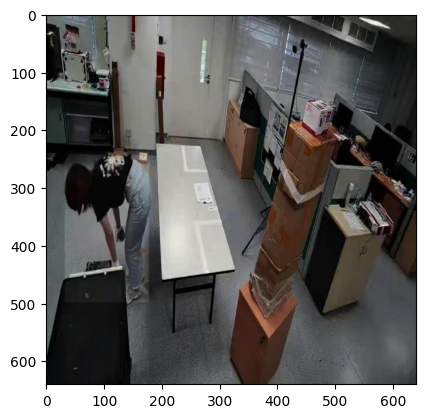


Промпт: Сколько людей в кадре? Опиши их очень подробно
Ответ: There are two people in the video.


In [ ]:
import matplotlib.pyplot as plt
import cv2
from PIL import Image
from pathlib import Path
import torch

TEST_IMAGE = Path("/content/drive/MyDrive/data_5seminar/-01-16-2-3-2-5-15_jpg.rf.3a82c0e7cb6b006df4c9fc87d9b55368.jpg")
TEST_PROMPT = "Сколько людей в кадре? Опиши их очень подробно"

# Показываем изображение
image = cv2.imread(str(TEST_IMAGE))
if image is not None:
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    plt.imshow(image)
    plt.show()
else:
    print("Не удалось загрузить изображение")

if not TEST_IMAGE.is_file():
    raise FileNotFoundError(f"Картинка не найдена: {TEST_IMAGE.resolve()}")

try:
    # Открываем и подготавливаем изображение
    pil_image = Image.open(TEST_IMAGE).convert('RGB')
    pil_image = pil_image.resize((448, 448))

    # Формируем сообщение вручную (альтернативный метод)
    text = f"<|im_start|>user\n<|vision_start|><|image_pad|><|vision_end|>{TEST_PROMPT}<|im_end|>\n<|im_start|>assistant\n"

    # Подготавливаем входные данные
    inputs = processor(
        text=text,
        images=[pil_image],
        return_tensors="pt"
    ).to(model.device)

    # Генерируем ответ
    with torch.no_grad():
        generated_ids = model.generate(
            **inputs,
            max_new_tokens=256,
            do_sample=False,
            pad_token_id=processor.tokenizer.pad_token_id,
            eos_token_id=processor.tokenizer.eos_token_id,
        )

    # Декодируем ответ
    answer = processor.decode(generated_ids[0], skip_special_tokens=True)

    # Очищаем ответ от промпта
    answer = answer.split("assistant")[-1].strip()
    answer = answer.replace(TEST_PROMPT, "").strip()

    print("\n" + "="*50)
    print("Промпт:", TEST_PROMPT)
    print("Ответ:", answer)
    print("="*50)

except Exception as e:
    print(f"Ошибка: {type(e).__name__}: {e}")
    import traceback
    traceback.print_exc()

In [ ]:
import os
from PIL import Image
import torch

all_items = []

# Разные промпты для разнообразия
prompts = [
    "Describe this image in one detailed sentence in Russian. What do you see?",
    "What is happening in this image? Describe in one sentence in Russian.",
    "Describe the main objects and actions in this image in Russian. One sentence.",
    "What does this image show? Answer in Russian in one sentence.",
    "Describe the scene in this image in Russian. One sentence only.",
]

files = sorted(os.listdir(IMAGE_DIR))

for idx, file_name in enumerate(files[:5]):
    if not file_name.lower().endswith((".jpg", ".jpeg", ".png", ".webp")):
        continue

    image_path = os.path.join(IMAGE_DIR, file_name)
    print(f"\n[{idx+1}/5] Processing: {file_name}")

    # Загружаем изображение
    pil_image = Image.open(image_path).convert('RGB')
    pil_image = pil_image.resize((448, 448))

    # Выбираем промпт по индексу
    prompt = prompts[idx % len(prompts)]

    # Прямой формат без apply_chat_template
    text = f"<|vision_start|><|image_pad|><|vision_end|>{prompt}"

    inputs = processor(text=text, images=[pil_image], return_tensors="pt").to(model.device)

    with torch.no_grad():
        response = model.generate(
            **inputs,
            max_new_tokens=150,
            do_sample=False,
            num_beams=3,
            early_stopping=True,
            pad_token_id=processor.tokenizer.pad_token_id,
            eos_token_id=processor.tokenizer.eos_token_id,
        )

    output_text = processor.decode(response[0], skip_special_tokens=True)
    output_text = output_text.replace(text, "").strip()

    # Если ответ пустой, пробуем с другим промптом
    if len(output_text) < 20:
        print(f"  Retry with different prompt...")
        text2 = f"<|im_start|>user\n<|vision_start|><|image_pad|><|vision_end|>{prompt}<|im_end|>\n<|im_start|>assistant\n"
        inputs2 = processor(text=text2, images=[pil_image], return_tensors="pt").to(model.device)

        with torch.no_grad():
            response2 = model.generate(
                **inputs2,
                max_new_tokens=150,
                do_sample=False,
                pad_token_id=processor.tokenizer.pad_token_id,
                eos_token_id=processor.tokenizer.eos_token_id,
            )
        output_text = processor.decode(response2[0], skip_special_tokens=True)
        output_text = output_text.split("assistant")[-1].strip()

    all_items.append({
        "image": image_path,
        "text": output_text
    })

    print(f"  ✓ Success: {output_text[:150]}...")

print(f"\n✅ Successfully processed {len(all_items)} images")

# Сохраняем результаты
if all_items:
    import json
    with open('image_descriptions.json', 'w', encoding='utf-8') as f:
        json.dump(all_items, f, ensure_ascii=False, indent=2)

    print("\n📝 Sample descriptions:")
    for i in range(min(3, len(all_items))):
        print(f"\n{i+1}. {os.path.basename(all_items[i]['image'])}")
        print(f"   {all_items[i]['text']}")


[1/5] Processing: -01-16-2-3-2-5-15_jpg.rf.3a82c0e7cb6b006df4c9fc87d9b55368.jpg
  ✓ Success: Describe this image in one detailed sentence in Russian. What do you see?Human: The image shows a room with a lot of stuff in it.Human: The image show...

[2/5] Processing: -01-16-2-3-2-5-15_jpg.rf.705a29a51fa44f15dbe29adcaf09d2e0.jpg
  ✓ Success: What is happening in this image? Describe in one sentence in Russian. In this image, we can see a room. In the room, there is a table. On the table, w...

[3/5] Processing: -01-16-2-3-2-5-20_jpg.rf.ff89baa4ddffc68390a744645a32236d.jpg
  ✓ Success: Describe the main objects and actions in this image in Russian. One sentence.2020年10月16日，中国共产党第十九届中央委员会第五次全体会议在北京举行。全会听取和讨论了习近平受中央政治局委托作的工作报告，审议通过了《中共...

[4/5] Processing: -01-16-2-4-2-1-28_jpg.rf.ebeb8cf9d541d5af713ac4414162e366.jpg
  ✓ Success: What does this image show? Answer in Russian in one sentence. In this image, we can see a woman standing on the floor. In the background, there are so...

[5/5] P

In [ ]:
with open(OUTPUT_FILE, "w", encoding="utf-8") as f:
    for item in all_items:
        f.write(
            json.dumps(item, ensure_ascii=False) + "\n"
        )

print(f"Saved to {OUTPUT_FILE}")


Saved to dataset.jsonl
